In [1]:
include("1body_NM.jl")
using LinearAlgebra
using PolyChaos
using QuadGK
using Plots
using ProgressMeter
using Kronecker
using JLD2
using SparseArrays
using .NM_measures_1body

P = set_P()
mu = 0.2
beta = 20.0
gamma = 0.01
T = 30.0
N = Int(T) 

P.spec_fun = "ellipse"
P.T = T
P.N_L = N
P.N_R = N
P.v = 1000
P.Γ_L = gamma
P.Γ_R = gamma
P.β_L = beta
P.β_R = beta
P.μ_L = mu
P.μ_R = mu

calculate_oCP(P; plotting=true)

P = set_P()
mu = 0.1
beta = 20.0
gamma = 0.01
T = 40.0
N = Int(T) 

P.spec_fun = "ellipse"
P.T = T
P.N_L = N
P.N_R = N
P.v = 1000
P.Γ_L = gamma
P.Γ_R = gamma
P.β_L = beta
P.β_R = beta
P.μ_L = mu
P.μ_R = mu

s_times = collect(0.1:0.1:20.0)

PTsignalling = zeros(length(s_times))
PTdivisibility = similar(PTsignalling)
for (i,s) in enumerate(s_times)
    C0 = prepare_corrs(P)
    T_choi = extract_process_tensor(P, C0, s, 2*s)
    PTsignalling[i], PTdivisibility[i] = calculate_PT_oCP(T_choi)
end

p = plot(s_times, PTsignalling, xlabel="\$t = 2s\$",ylabel="Signalling from \$ s \\rightarrow t\$", label="Signalling",
        legend=:topleft, lw=2, dpi=400)
plot!(twinx(p), s_times, PTdivisibility, ylabel="\$||L_{t:0} - L_{t:s:0}||\$", label="Divisibility",legend=:topright, lw=2, c=:red)

display(p)
    
        



Progress: 100%|█████████████████████████████████████████| Time: 0:47:36


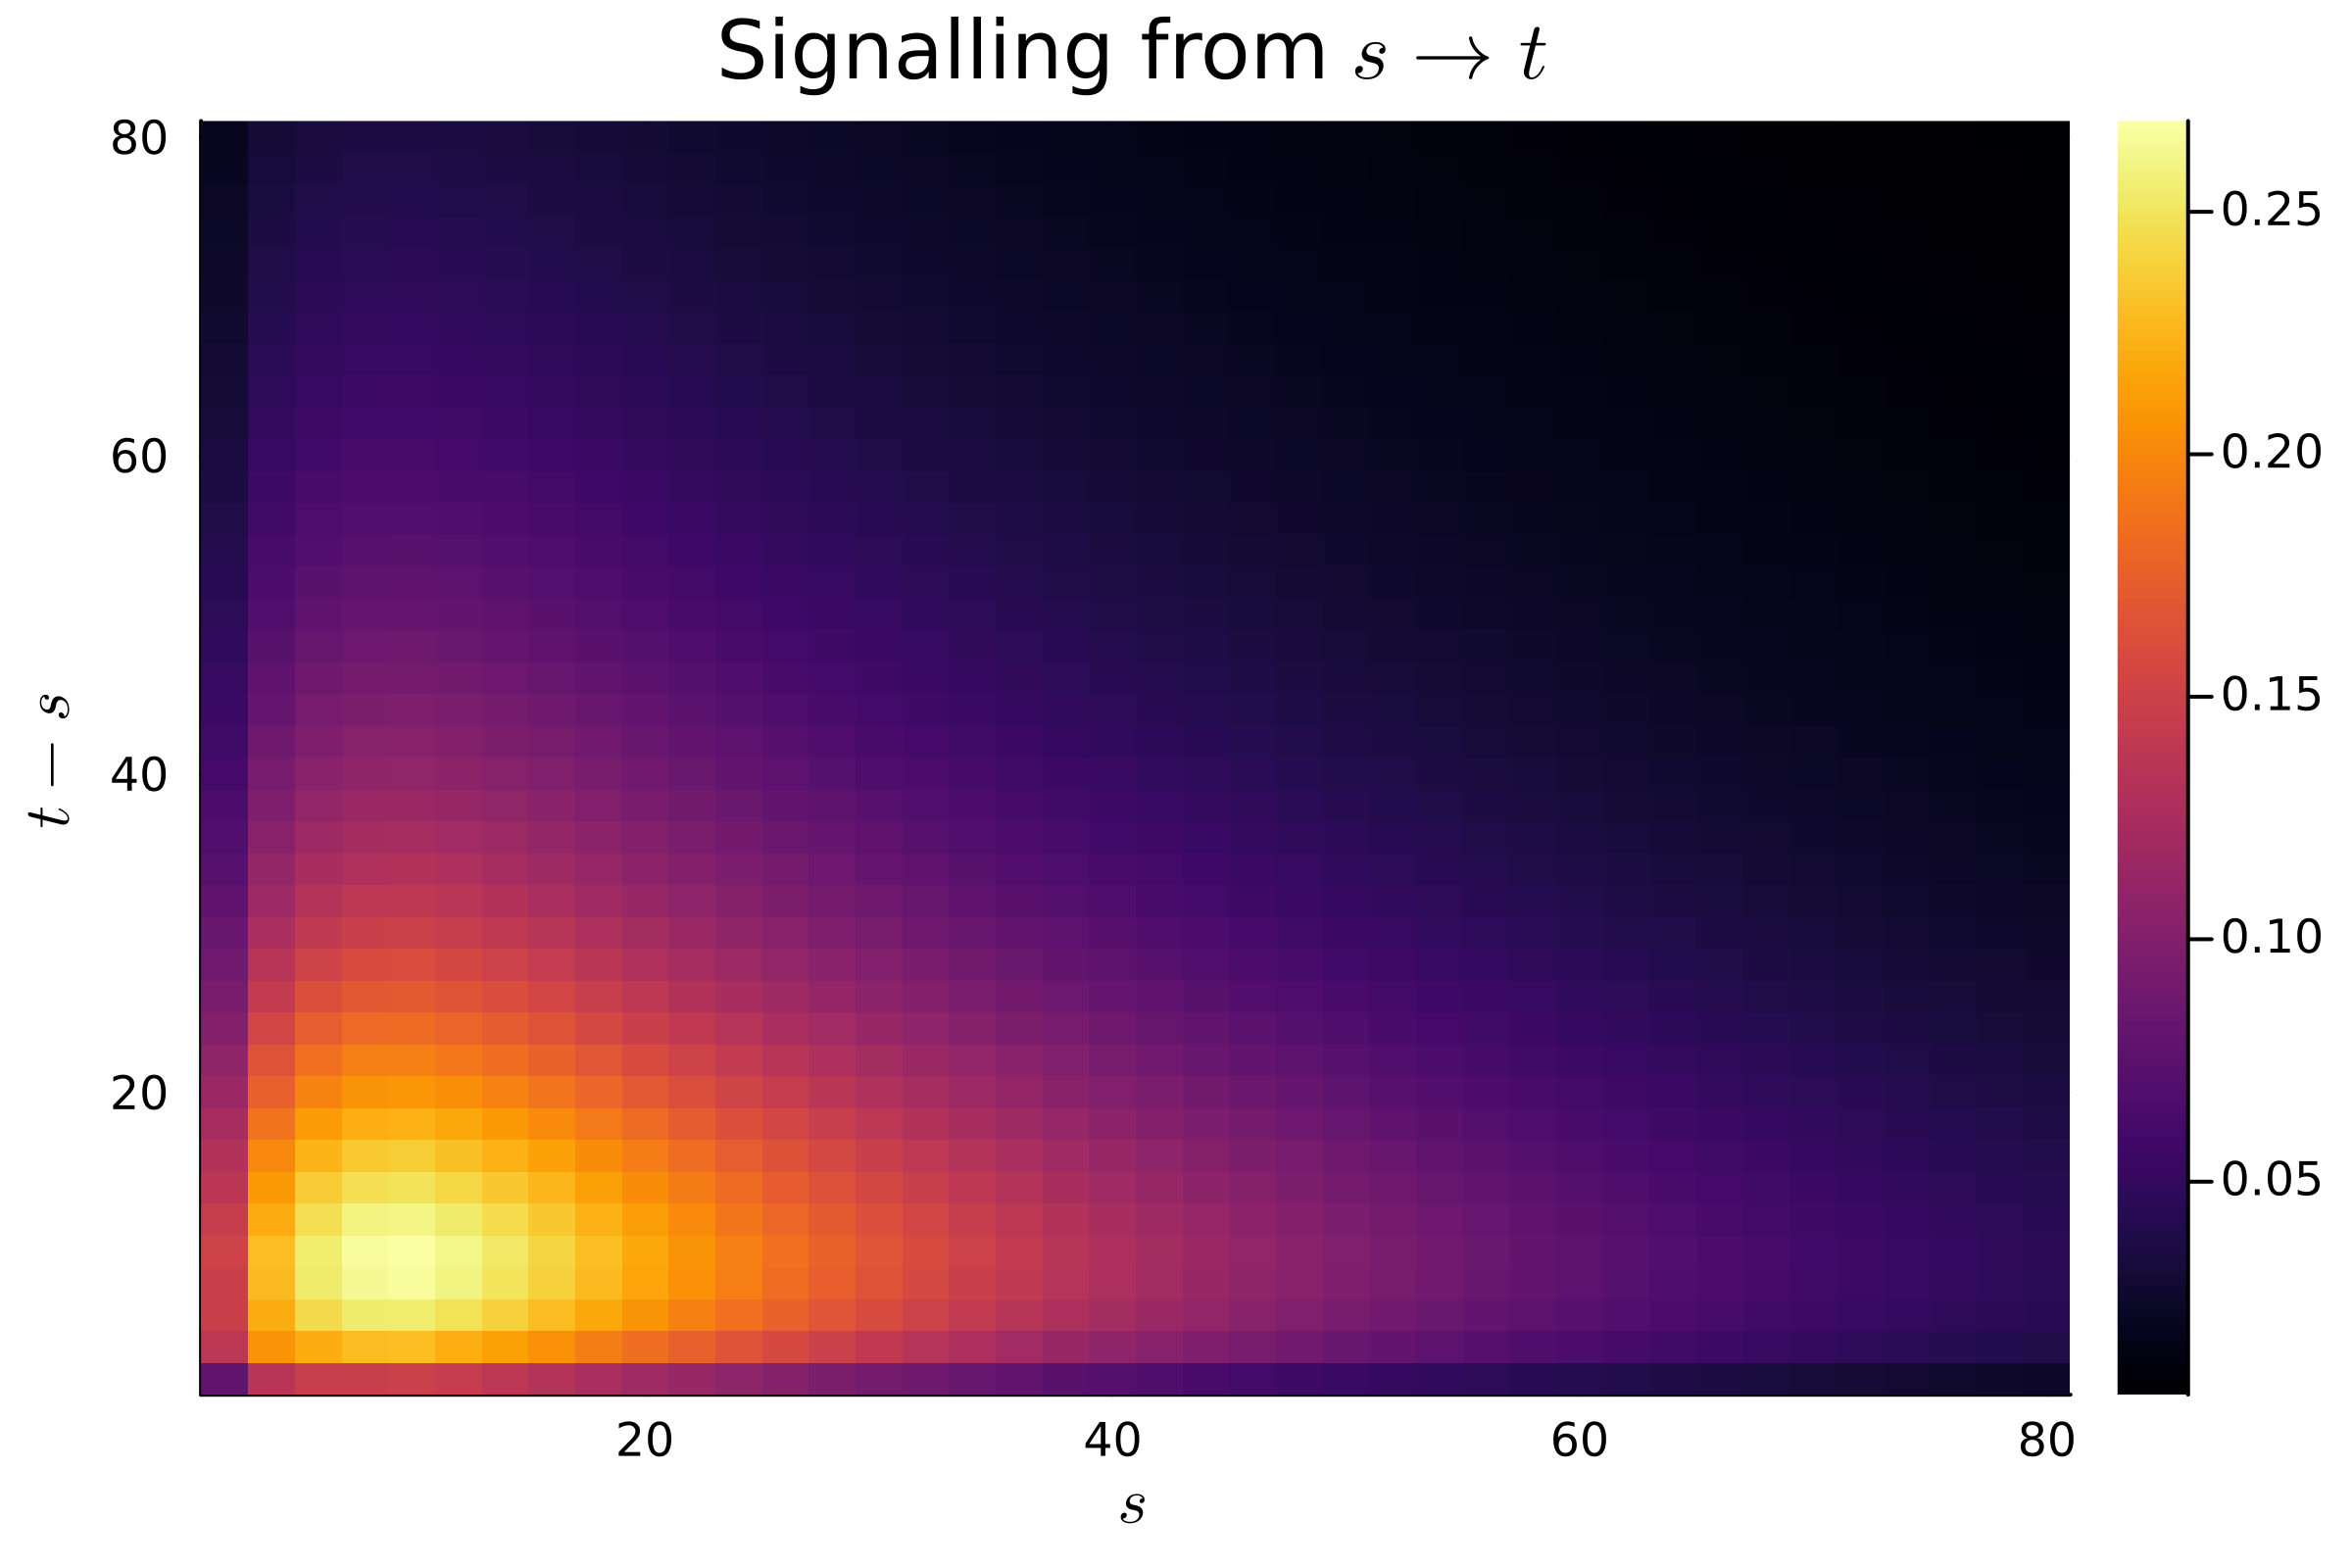

"p = heatmap(s_times, times, PTdivisibility, xlabel=\"\$s\$\", ylabel=\"\$t\$\",\n             title=\"\$ \\frac{1}{2} ||L_{t:0} - L_{t:s:0}|| \$\", dpi=400)\ndisplay(p)\n"

In [ ]:
P = set_P()
mu = 0.1
beta = 20.0
gamma = 0.02
T = 60.0

P.spec_fun = "ellipse"
P.v = 1000
P.Γ_L = gamma
P.Γ_R = gamma
P.β_L = beta
P.β_R = beta
P.μ_L = mu
P.μ_R = mu

step = 2.0
s_times = collect(step:step:T) 

PTsignalling = zeros(length(s_times),length(s_times))
Gsignalling = zeros(length(s_times),length(s_times))
#PTdivisibility = zeros(length(times),length(times))
@showprogress for (j,s) in enumerate(s_times)
    t_times = s_times .+ s
    for (i,t) in enumerate(t_times)
        t = t_times[i]
        P.T = t
        N = Int(round(t/2)) + 5
        P.N_L = N
        P.N_R = N  
        C0 = prepare_corrs(P)
        T_choi = extract_process_tensor(P, C0, s, t)
        PTsignalling[i,j], Gsignalling[i,j] = calculate_PT_oCP(T_choi)
    end
end

p = heatmap(s_times, s_times, PTsignalling, xlabel="\$s\$", ylabel="\$t-s\$", title="Signalling from \$s \\rightarrow t\$",
        dpi=400)
display(p)

p = heatmap(s_times, s_times, Gsignalling, xlabel="\$s\$", ylabel="\$t-s\$", title="Signalling from \$s \\rightarrow t\$ (From G)",
        dpi=400)
display(p)
"""
p = heatmap(s_times, times, PTdivisibility, xlabel="\$s\$", ylabel="\$t\$",
             title="\$ \\frac{1}{2} ||L_{t:0} - L_{t:s:0}|| \$", dpi=400)
display(p)
"""

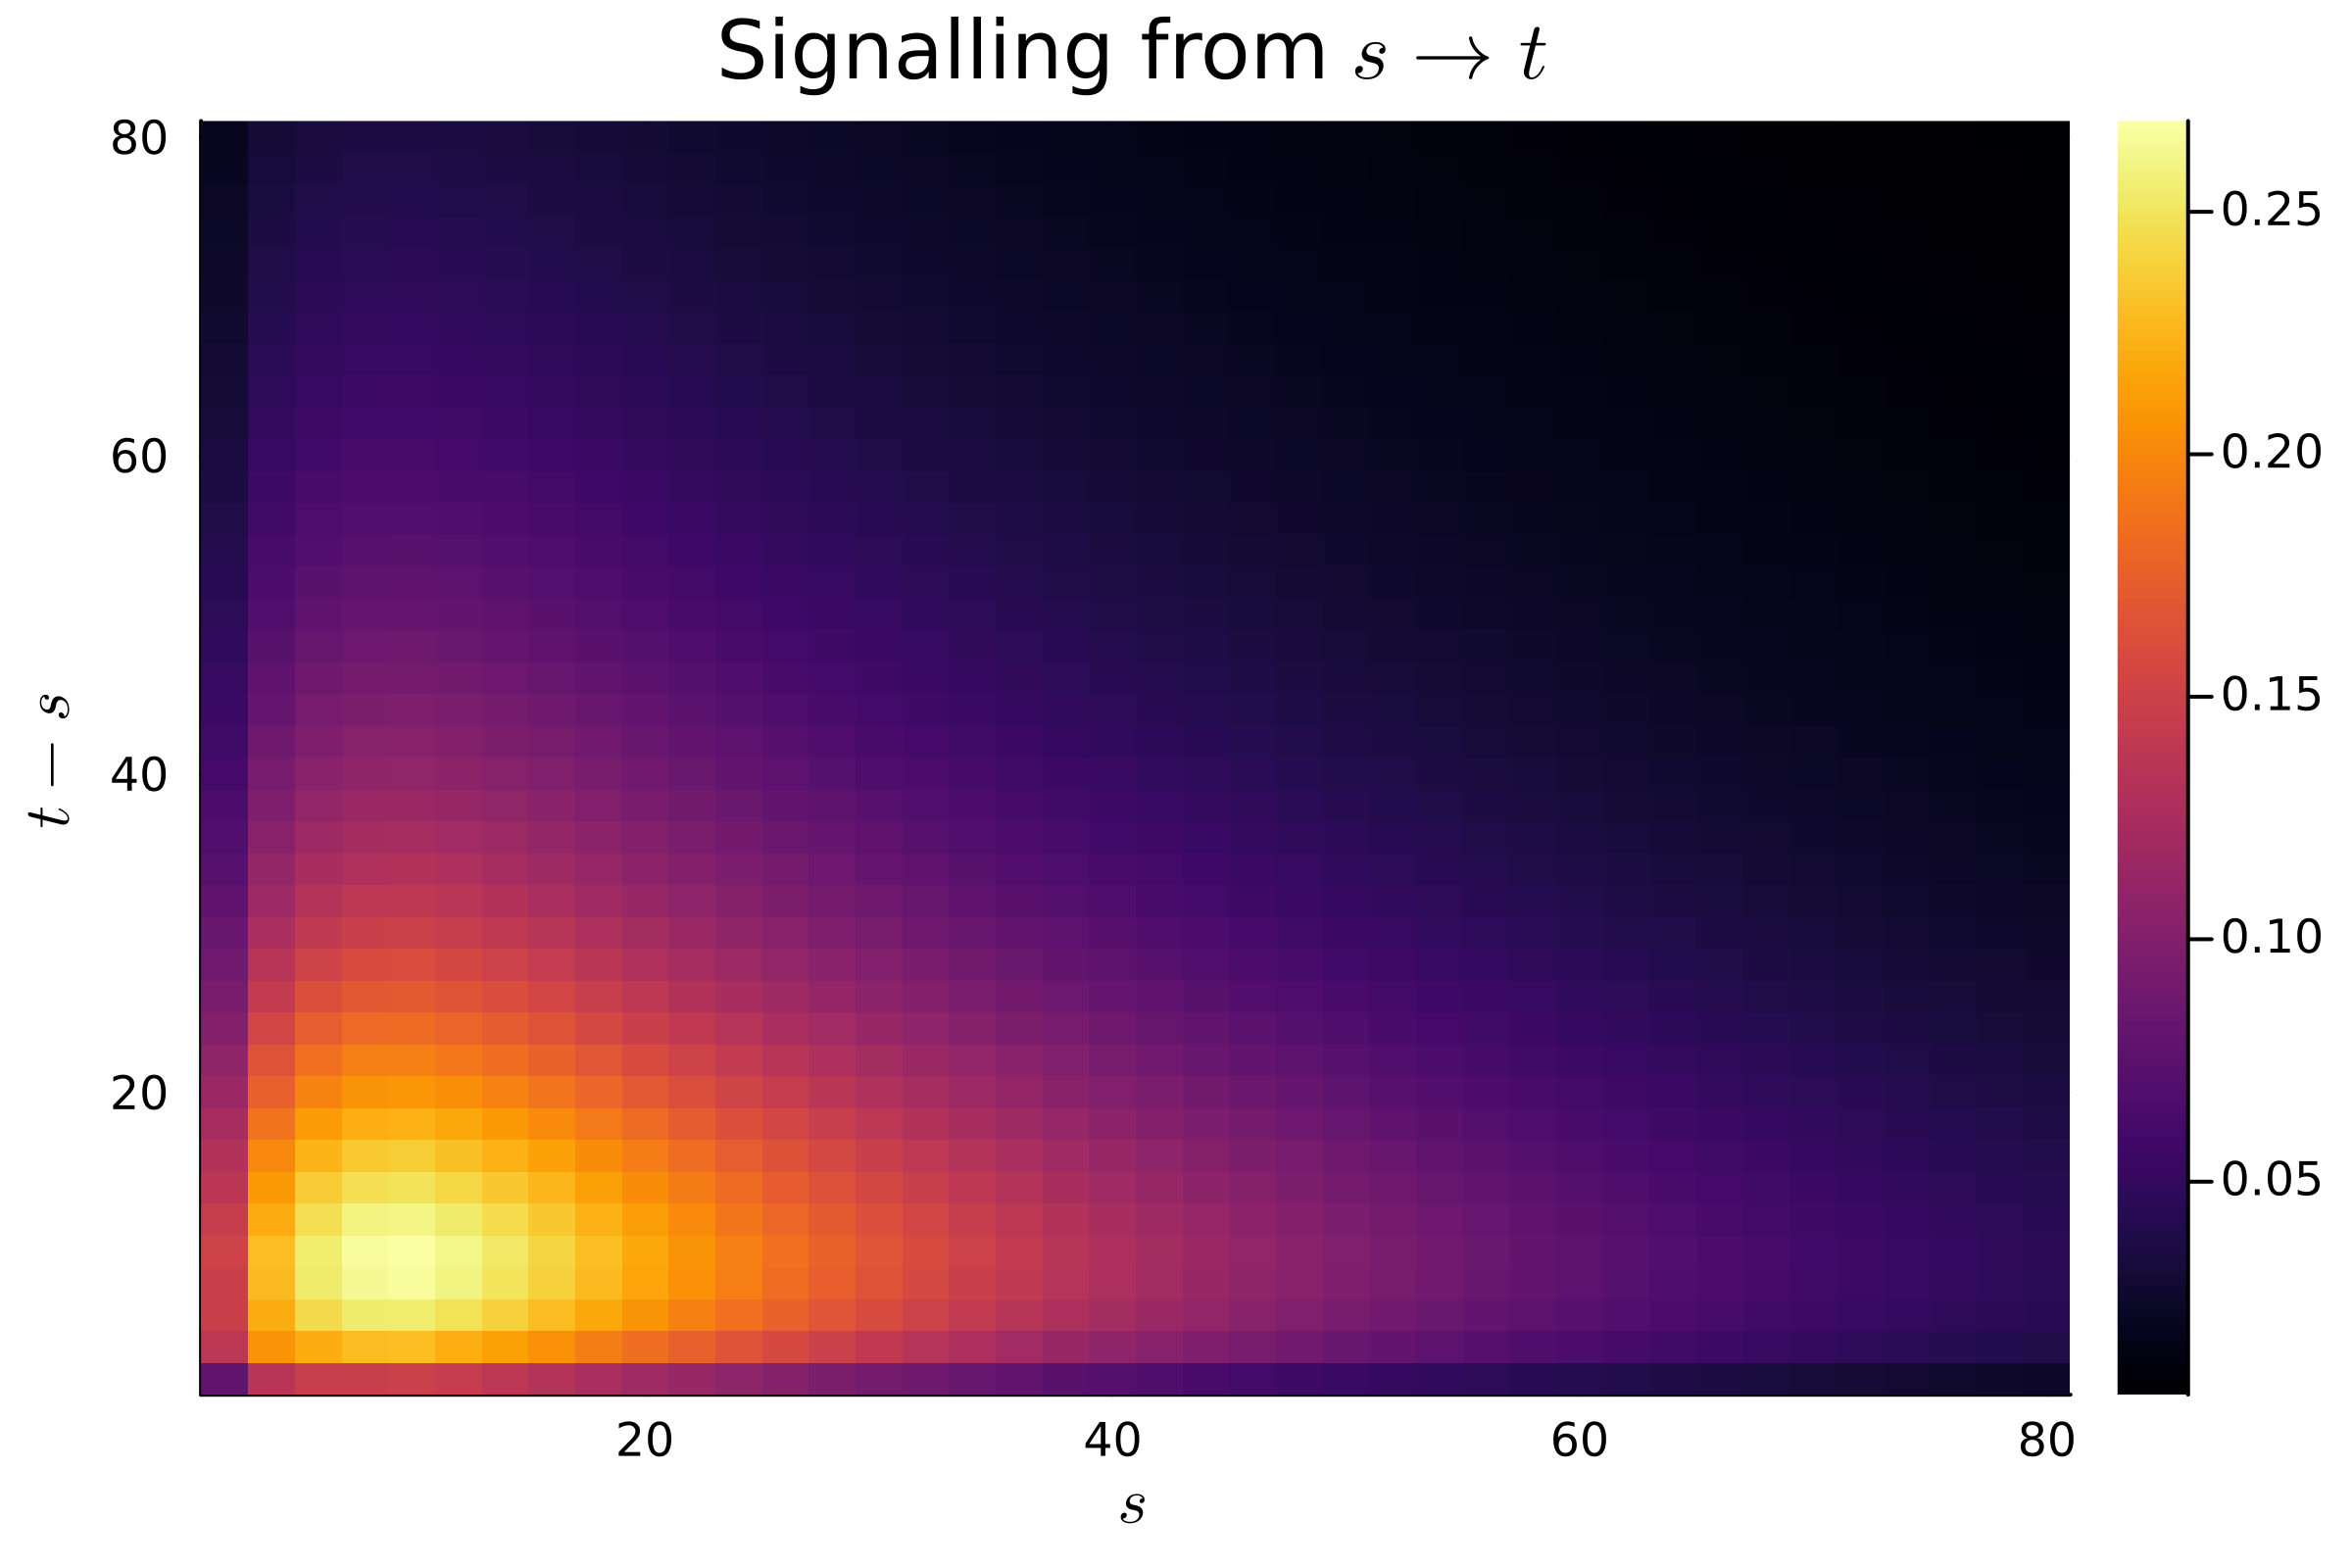

In [3]:
p = heatmap(s_times, s_times, PTsignalling, xlabel="\$s\$", ylabel="\$t-s\$", title="Signalling from \$s \\rightarrow t\$",
        dpi=400)
display(p)